# 道路修復時間資料分析

1. **資料讀取**
   - 載入 `data/road_clean.csv`
   - 確認欄位與資料筆數

2. **探索性分析（EDA）**

   2.1 基本統計
   - 計算 `Duration (minutes)` 的 mean、median、std、min、max
   - 可觀察中位數遠小於平均值之重尾現象

   2.2 各災害種類的 Duration 統計
   - 以 `Cause` 為分組依據，計算各類別統計量

   2.3 Cause 分布統計
   - 計算各 Cause 類別的筆數與佔比，繪製圓餅圖

3. **高雄市 Cause 發生比例**
   - 篩選高雄市資料，計算各 Cause 發生比例
   - 資料來源為全台公路局養護路網，落石比例偏高，不能直接反映高雄市區的災害組成
   - 採用高雄市實際觀測的 Cause 比例作為後續模擬中災害類型發生機率之依據
   - 修復時間分布以全台資料擬合，保留完整重尾資訊，不進行分層取樣

4. **CCDF 計算與繪製**
   - 以全台資料計算各 Cause 的經驗 CCDF：P(X > x)，以 log-log 尺度呈現
   - 作為後續分布擬合候選函式選定之依據

5. **多分布擬合（MLE + AIC）**
   - 以全台各 Cause 全量資料進行擬合，保留完整尾部資訊
   - 候選分布依據 CCDF 形狀決定
   - 以 MLE 估計參數，以 AIC 與 KS D 統計量作為模型選擇依據
   - 單一分布擬合效果不佳，尾部低估明顯，進一步採用 GMM 改善

6. **Gaussian Mixture Model（GMM）擬合**
   - 對 log(Duration) 進行 GMM 擬合，等同 Log-normal Mixture
   - 以 BIC 選定各 Cause 最佳 component 數
   - 以 Stratified K-Fold Cross-Validation 驗證模型泛化能力
   - 以分位數比較（P50／P25／P10／P5／P1）量化擬合品質

7. **成果存檔**
   - 高雄市各 Cause 發生比例
   - 各 Cause GMM 參數（weights、means、stds）
   - 統一寫入 `data/road_repair_params.json`

* **與電網資料不同處** : 依據高雄市區道路損壞原因的分佈機率，再依據該機率得出的修復時間分佈曲線做模擬 (在 第 3 節有較清楚的說明)，並才用 GMM 的 ML 方式進行擬合

# 1. 資料讀取

In [196]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "road_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：10289
欄位：['轄管局處段', '通報時間', '實際解除時間', '路線', '災害主次類別', '管制原因', 'Duration (minutes)', 'Duration (days)', 'Cause', 'year']


,轄管局處段,通報時間,實際解除時間,路線,災害主次類別,管制原因,Duration (minutes),Duration (days),Cause,year
0,交通部公路局 北區養護工程分局 復興工務段,2014-06-05 06:52:00,2014-06-05 09:00:00,省道台7線37K+700~37K+700,道路 道路落石,零星落石,128.0,0.1,Rockfall,2014
1,交通部公路局 北區養護工程分局 復興工務段,2014-06-06 20:40:00,2014-06-06 22:00:00,省道台7線35K+500~35K+500,道路 道路落石,零星落石,80.0,0.1,Rockfall,2014
2,交通部公路局 北區養護工程分局 復興工務段,2014-06-23 07:14:00,2014-06-23 09:55:00,省道台7線19K+500~19K+500,道路 道路落石,零星落石,161.0,0.1,Rockfall,2014
3,交通部公路局 雲嘉南區養護工程分局 阿里山工務段,2014-06-01 01:00:00,2014-06-01 03:00:00,省道台18線72K+500~72K+500,道路 道路落石,零星落石,120.0,0.1,Rockfall,2014
4,交通部公路局 雲嘉南區養護工程分局 阿里山工務段,2014-06-09 07:20:00,2014-06-09 09:20:00,省道台18線72K+500~72K+500,道路 道路落石,零星落石,120.0,0.1,Rockfall,2014


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄道路封閉修復時間的 mean、median、std、min、max 等資訊
* 若中位數遠小於平均值，代表存在重尾現象，即極端事件拉高整體平均修復時間

In [197]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,490.62
Median,89.00
Std,6113.32
Min,0.42
Max,436409.75


## 2.2 各災害種類的 Duration 統計

In [198]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Natural Disaster,1219,2303.86,184.48,17261.82,1.03,436409.75
Other,1088,351.06,115.00,1324.72,0.42,20030.00
Rockfall,7790,230.37,71.00,1377.39,0.73,43260.00
Traffic Accident,192,328.54,105.50,1285.63,6.00,10247.65


## 2.3 Cause 分布統計

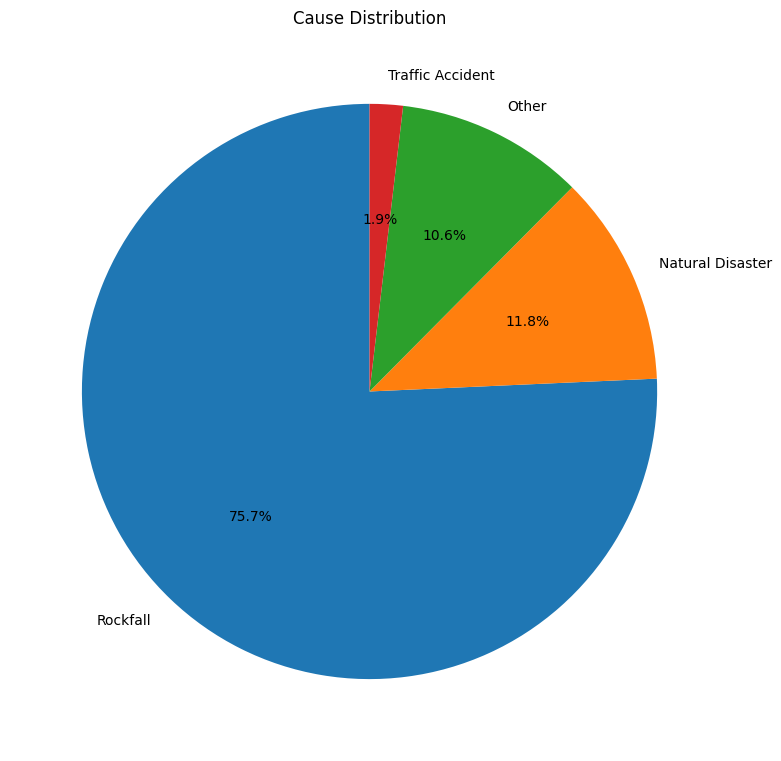

In [199]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

# 3. 高雄市 Cause 發生比例

由 EDA 可以發現落石的比例過高，主要原因為資料來源為公路總局，故資料集中在省道的部分，故山區落石造成道路中斷的機率較市區內較封閉的道路高很多，由於我們要分析高雄市區的道路損壞程度機率，但若採用分層取樣我會認為會無法處理重尾分佈的現象，因為髓機取樣取到重尾的機率很低，故不採用

後續採用，依據高雄市區道路損壞原因的分佈機率，再依據該機率得出的修復時間分佈曲線做模擬

## 3.1 高雄市道路事件分佈比例

In [200]:
# 篩選高雄市資料
df_kaohsiung = df[df["轄管局處段"].str.contains("高雄", na=False)].copy()
print(f"高雄市資料筆數：{len(df_kaohsiung)}")
print()

# 高雄 Cause 發生比例
kaohsiung_ratio = (
    df_kaohsiung["Cause"]
    .value_counts(normalize=True)
    .rename_axis("Cause")
    .reset_index(name="Ratio")
)
kaohsiung_ratio["Ratio"] = kaohsiung_ratio["Ratio"].round(4)
kaohsiung_ratio

高雄市資料筆數：187



,Cause,Ratio
0,Other,0.5722
1,Natural Disaster,0.2406
2,Rockfall,0.1818
3,Traffic Accident,0.0053


Other 有點高，偷瞄一眼不分類實際分佈

In [201]:
# 高雄市 災害主次類別 分布
kh_detail = (
    df_kaohsiung["災害主次類別"]
    .value_counts()
    .rename_axis("災害主次類別")
    .reset_index(name="Count")
)
kh_detail["Pct (%)"] = (kh_detail["Count"] / len(df_kaohsiung) * 100).round(1)
kh_detail

,災害主次類別,Count,Pct (%)
0,道路 其他,92,49.2
1,道路 道路落石,34,18.2
2,道路 邊坡坍方,19,10.2
3,其他 其他,15,8.0
4,道路 土石流阻斷,14,7.5
5,道路 淹水,11,5.9
6,道路 路基流失,1,0.5
7,道路 交通事故(含危險品洩漏疑慮、火災),1,0.5


## 3.2 視覺化

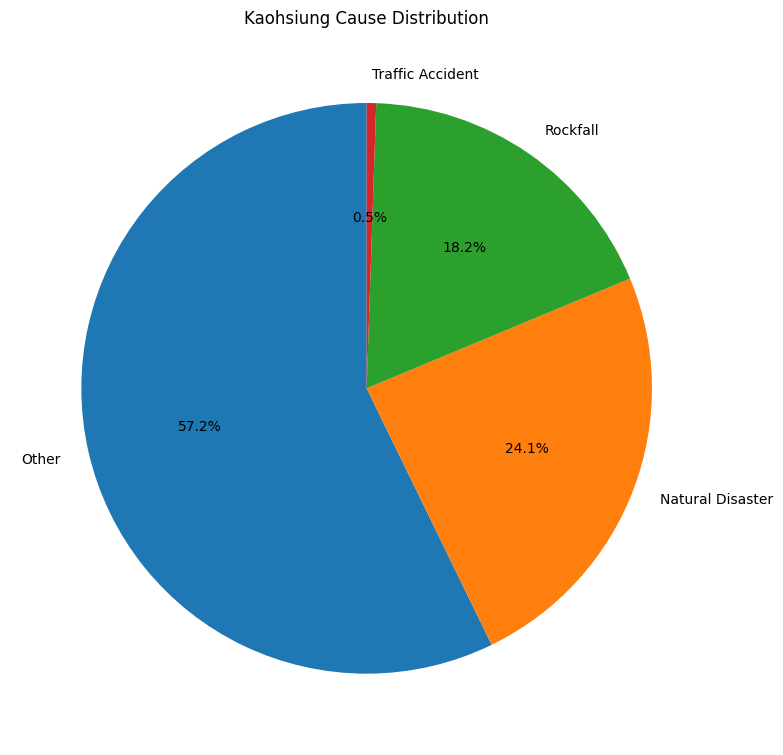

In [202]:
# 圓餅圖
kaohsiung_counts = df_kaohsiung["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(kaohsiung_counts, labels=kaohsiung_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Kaohsiung Cause Distribution")
plt.tight_layout()
plt.show()

# 4. CCDF 計算與繪製

* 使用全台資料，依 Cause 分組繪製經驗 CCDF，以 log-log 尺度呈現，作為後續分布擬合候選函式選定之依據

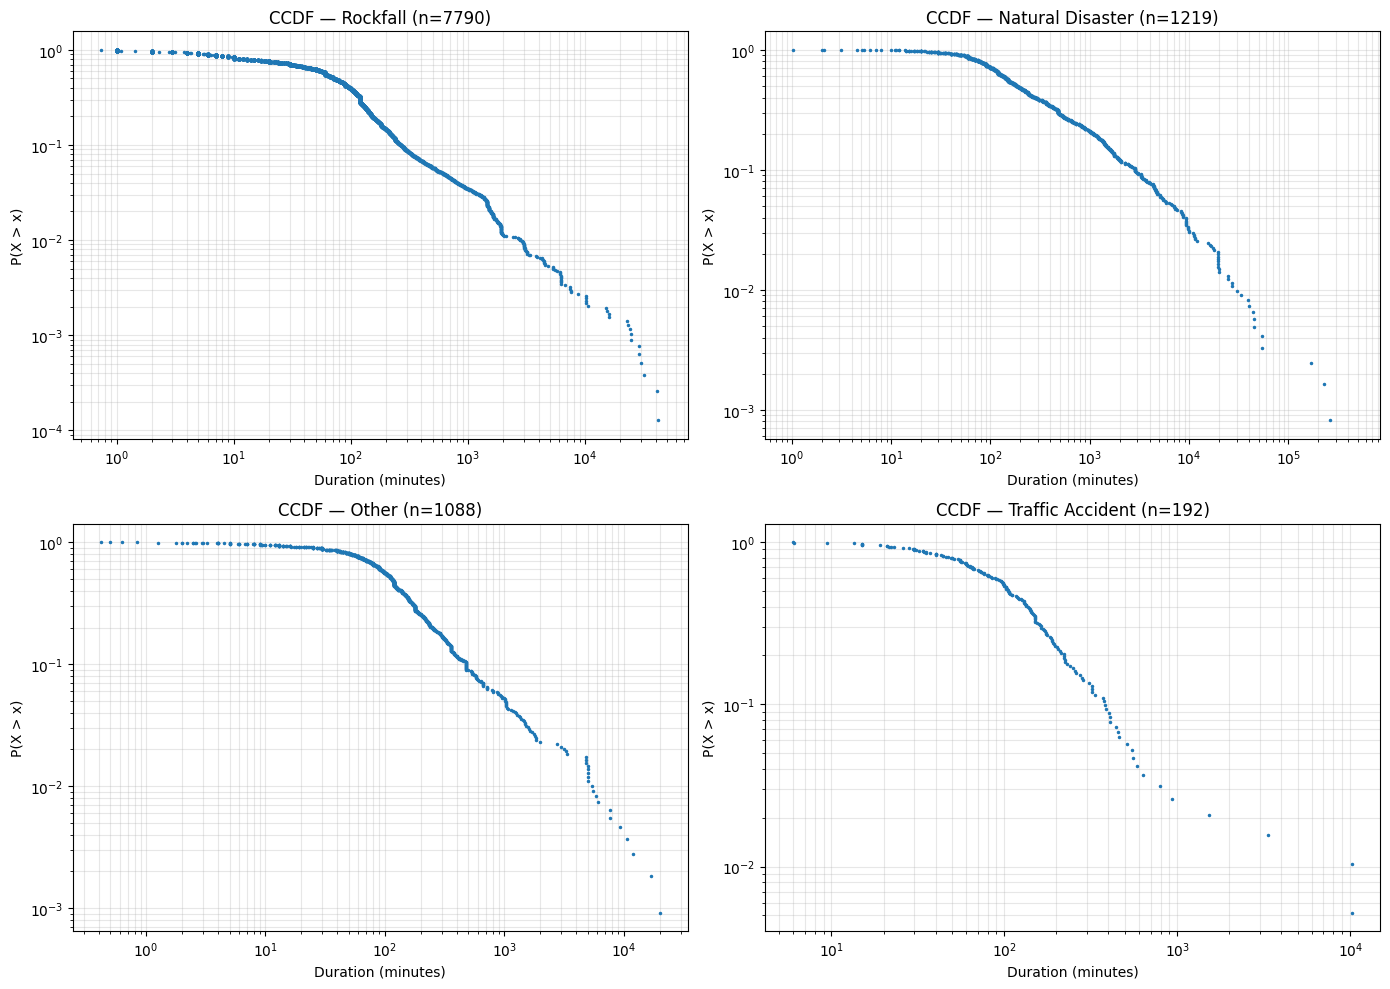

In [203]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

causes = df["Cause"].unique()

for i, cause in enumerate(causes):
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf = 1 - np.arange(1, len(data) + 1) / len(data)

    axes[i].loglog(data, ccdf, marker=".", linestyle="none", markersize=3)
    axes[i].set_title(f"CCDF — {cause} (n={len(data)})")
    axes[i].set_xlabel("Duration (minutes)")
    axes[i].set_ylabel("P(X > x)")
    axes[i].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 多分布擬合（MLE + AIC）

* 各 Cause CCDF 觀察

  * **Rockfall / Natural Disaster / Other**
      
      三類別在 log-log 尺度下皆呈現明顯向下彎曲弧線，為典型 Log-normal 分布特徵，與電網修復時間資料之結論一致，顯示修復時間具有重尾特性，極端事件發生機率高於指數分布之預期

  * **Traffic Accident**

      與其他三類別明顯不同，在 10 ~ 1,000 分鐘區間呈現近似線性下降，尾部衰減較快，較接近 Weibull 或 Exponential 分布之行為，語義上亦合理

* 候選分布

    | Cause | 候選分布 |
    |---|---|
    | Rockfall | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |
    | Natural Disaster | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |
    | Other | Log-normal、Weibull、Gamma、Burr (XII)、Gen. Pareto、Gen. Gamma |
    | Traffic Accident | Exponential、Weibull、Log-normal、Gamma |

## 5.1 函式擬合

In [204]:
from scipy import stats

# 候選分布定義
candidates_main = {
    "Log-normal"  : stats.lognorm,
    "Weibull"     : stats.weibull_min,
    "Gamma"       : stats.gamma,
    "Burr (XII)"  : stats.burr,
    "Gen. Pareto" : stats.genpareto,
    "Gen. Gamma"  : stats.gengamma,
}

candidates_traffic = {
    "Exponential" : stats.expon,
    "Weibull"     : stats.weibull_min,
    "Log-normal"  : stats.lognorm,
    "Gamma"       : stats.gamma,
}

cause_candidates = {
    "Rockfall"         : candidates_main,
    "Natural Disaster" : candidates_main,
    "Other"            : candidates_main,
    "Traffic Accident" : candidates_traffic,
}

fit_results   = {}
fitted_params = {}

for cause, candidates in cause_candidates.items():
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    rows = []
    fitted_params[cause] = {}

    for name, dist in candidates.items():
        try:
            params  = dist.fit(data, floc=0)
            log_lik = np.sum(dist.logpdf(data, *params))
            k       = len(params)
            aic     = 2 * k - 2 * log_lik
            ks_d, _ = stats.kstest(data, lambda x: dist.cdf(x, *params))

            rows.append({"Distribution": name, "AIC": round(aic, 2), "KS D": round(ks_d, 4)})
            fitted_params[cause][name] = (dist, params)

        except Exception as e:
            print(f"[{cause}] {name} 擬合失敗：{e}")

    result_df = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    fit_results[cause] = result_df
    print(f"=== {cause} (n={len(data)}) ===")
    print(result_df.to_string(index=False))
    print()

=== Rockfall (n=7790) ===
Distribution      AIC   KS D
  Burr (XII) 91144.41 0.0632
 Gen. Pareto 91305.49 0.0790
  Gen. Gamma 91672.05 0.0895
  Log-normal 91693.06 0.1112
     Weibull 92930.77 0.1156
       Gamma 95405.46 0.2024

=== Natural Disaster (n=1219) ===
Distribution      AIC   KS D
  Burr (XII) 18249.34 0.0588
 Gen. Pareto 18356.47 0.0891
  Log-normal 18385.71 0.1028
  Gen. Gamma 18524.62 0.1131
     Weibull 18885.74 0.1489
       Gamma 19517.51 0.2454

=== Other (n=1088) ===
Distribution      AIC   KS D
  Burr (XII) 13851.65 0.0581
 Gen. Pareto 13951.33 0.1050
  Log-normal 13978.55 0.0872
  Gen. Gamma 14015.86 0.1034
     Weibull 14312.41 0.1428
       Gamma 14598.39 0.2180

=== Traffic Accident (n=192) ===
Distribution     AIC   KS D
  Log-normal 2400.90 0.0801
     Weibull 2503.68 0.1589
       Gamma 2563.90 0.2437
 Exponential 2613.15 0.3232



## 5.2 視覺化

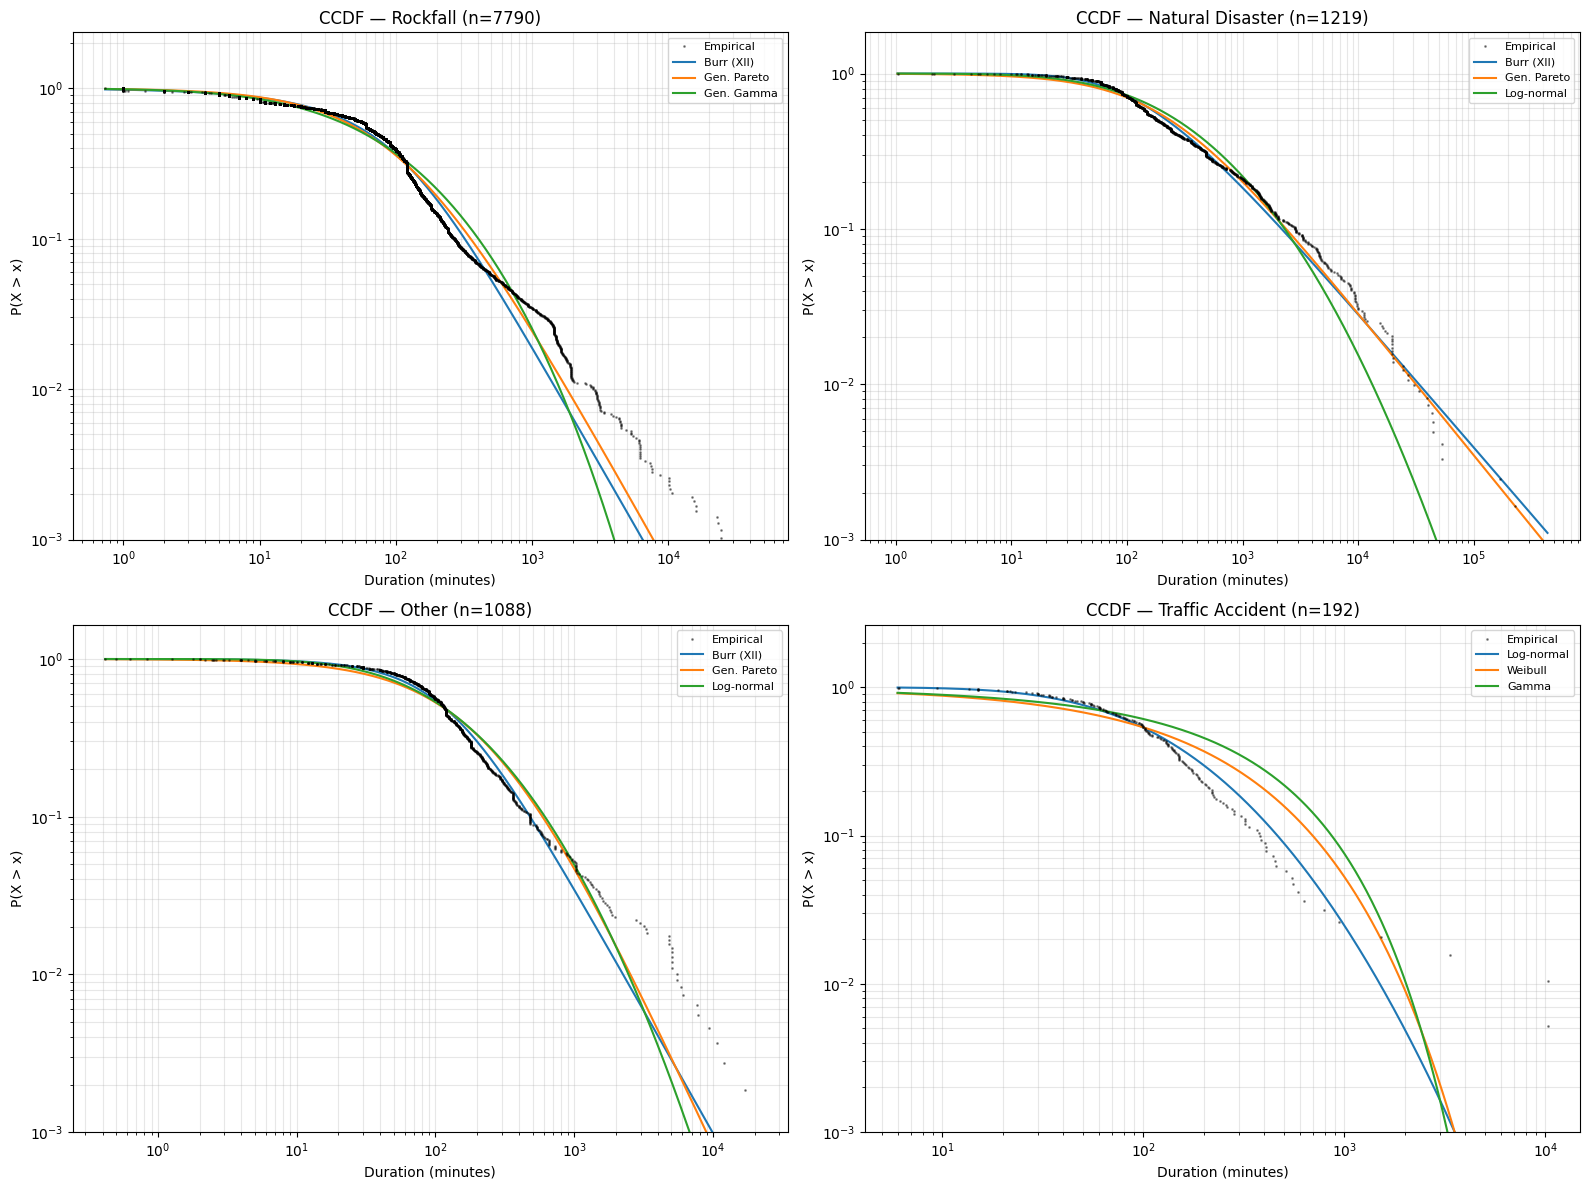

In [205]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ["tab:blue", "tab:orange", "tab:green"]

for i, cause in enumerate(cause_candidates.keys()):
    data   = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf   = 1 - np.arange(1, len(data) + 1) / len(data)
    x_plot = np.logspace(np.log10(data.min()), np.log10(data.max()), 600)

    ax = axes[i]

    # 實際 CCDF
    ax.loglog(data, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical", zorder=5)

    # 依 AIC 取前三名
    top3 = fit_results[cause].head(3)["Distribution"].tolist()
    for name, color in zip(top3, colors):
        dist, params = fitted_params[cause][name]
        ccdf_th      = 1 - dist.cdf(x_plot, *params)
        ax.loglog(x_plot, ccdf_th, color=color, linewidth=1.5, label=name)

    ax.set_title(f"CCDF — {cause} (n={len(data)})")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("P(X > x)")
    ax.set_ylim(bottom=1e-3)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Gaussian Mixture Model（GMM）

* 因為擬合實在太醜了，改用 ML 方式處理

1. **基本概念**

    * GMM : 是一種機率模型，假設資料是由多個高斯分布（常態分布）混合而成，每個高斯分布代表一個「子族群」，整體分布是這些子族群的加權總和：

        $$p(x) = \sum_{n=1}^{N} \pi_k \cdot \mathcal{N}(x \mid \mu_k, \sigma_k^2)$$

        | 符號 | 意義 |
        | :---: | :--- |
        | $N$ | component 數（子族群數量） |
        | $\pi_k$ | 第 $k$ 個 component 的權重（$\sum \pi_k = 1$） |
        | $\mu_k$ | 第 $k$ 個 component 的平均值 |
        | $\sigma_k^2$ | 第 $k$ 個 component 的變異數 |

    &nbsp;

    * 概念上類似於，將資料點切分為好幾個族群，再依據該族群計算出 (平均值、標準差) 做常態分佈，然後乘上族群數量權重後加總整體擬合

    * 對應到道路修復時間的物理意義為，對 $\log(\text{Duration})$ 做 GMM，等同於 **Log-normal Mixture**，每個 component 對應一種修復情境，舉例如下：

        | Component | 物理意義 | Duration 範圍 |
        | :---: | :--- | :---: |
        | 短期 | 零星落石清除、輕微事故 | $< 2$ 小時 |
        | 中期 | 中規模坍方、道路修復 | $2$ 小時 $\sim 1$ 天 |
        | 長期 | 大規模災害、結構性修復 | $> 1$ 天 |

    &nbsp;

1. **參數估計：EM 演算法**

    GMM 透過 **Expectation-Maximization（EM）演算法** 估計參數：

    1. **E step**：計算每個資料點屬於各 component 的機率
    2. **M step**：依據該機率更新各 component 的 $\pi_k$、$\mu_k$、$\sigma_k^2$
    3. 反覆迭代直到收斂

2. **模型選擇：BIC**

    以 **BIC（Bayesian Information Criterion）** 選擇最佳 component 數 $K$，
    BIC 在 log-likelihood 的基礎上對參數數量進行懲罰，避免過擬合 ( 數值越小代表模型越佳 )：

    $$BIC = k \ln(n) - 2\ln(\hat{L})$$

    &nbsp;

    | 符號 | 意義 | 在本研究中 |
    |---|---|---|
    | $k$ | 模型的自由參數數量 | 每個 component 有 3 個參數（$\pi_k$、$\mu_k$、$\sigma_k^2$），故 $k = 3 \times K - 1$（權重加總為 1，少一個自由度） |
    | $n$ | 資料筆數 | 各 Cause 的樣本數 |
    | $\hat{L}$ | 最大化後的 likelihood | EM 收斂後模型對全量資料的擬合程度，即 $\prod_{i=1}^{n} p(x_i \mid \hat{\theta})$ |

    &nbsp;


3. **模型泛化能力評估：Stratified K-Fold**

    * 處理資料類別不平衡的問題 : 

        由於修復時間具有重尾特性，極端事件佔比極少，若使用隨機 K-Fold 取樣，test fold 可能完全不含尾部資料，無法有效評估尾部擬合品質。

        因此採用 **Stratified K-Fold**，對 Duration 先做離散化分層，確保每個 fold 都包含各區間的資料比例

4. **模型泛化能力評估 : log-likelihood**

    * K-Fold 切分了不同的資料集( $x_i$ : duration 不同)，為了確定模型泛化能力，針對每個 Fold 計算 $\mathcal{L}$ (likelihood)，觀察彼此之間在同一組參數下的相似度是否差距過大

    * Log-likelihood 泛化能力評估指標 :

        對於 GMM，資料點 $x_i$ 的 likelihood 為模型對該點 duration 的發生機率估計值：

        $$\mathcal{L}(\theta) = \prod_{i=1}^{n} p(x_i \mid \theta) = \prod_{i=1}^{n} \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)$$

        取對數後轉為加法形式 ：

        $$\log \mathcal{L}(\theta) = \sum_{i=1}^{n} \log \left( \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x_i \mid \mu_k, \sigma_k^2) \right)$$


## 6.1 Duration 離散化分層

In [206]:
import numpy as np
import pandas as pd

# Traffic Accident 排除（樣本過少）
causes_fit = ["Rockfall", "Natural Disaster", "Other"]

# 設定區間 : [0, 1 小時, 6小時, 1 天, 無限]
bins   = [0, 60, 360, 1440, np.inf]
labels = ["< 1hr", "1~6hr", "6hr~1day", "> 1day"]

# 建立區間欄位
df["duration_bin"] = pd.cut(df["Duration (minutes)"], bins=bins, labels=labels)

# 確認分層分布
for cause in causes_fit:
    data_cause = df[df["Cause"] == cause]
    print(f"=== {cause} ===")
    bin_count = data_cause["duration_bin"].value_counts().sort_index()
    bin_pct  = (bin_count / len(data_cause) * 100).round(1)
    display(pd.DataFrame({"Count": bin_count, "Pct (%)": bin_pct}))
    print()

=== Rockfall ===


,Count,Pct (%)
duration_bin,,
< 1hr,3521,45.2
1~6hr,3694,47.4
6hr~1day,389,5.0
> 1day,186,2.4



=== Natural Disaster ===


,Count,Pct (%)
duration_bin,,
< 1hr,175,14.4
1~6hr,604,49.5
6hr~1day,247,20.3
> 1day,193,15.8



=== Other ===


,Count,Pct (%)
duration_bin,,
< 1hr,267,24.5
1~6hr,682,62.7
6hr~1day,101,9.3
> 1day,38,3.5


## 6.2 超參數 $N$ 選擇

* 對 n_components 由 1~5 進行窮舉搜尋，後以 BIC 作為模型選擇準則，取 BIC 最小者作為最佳 component 數

In [216]:
from sklearn.mixture import GaussianMixture

# 使用 BIC 指標找出各 Cause 最佳 component 數量 function 
def fit_gmm(data, max_components=5):
    log_data   = np.log(data).reshape(-1, 1)
    best_gmm   = None
    best_bic   = np.inf
    bic_scores = []

    # 根據不同族群 n (component) 計算 BIC 指標
    for n in range(1, max_components + 1):
        gmm = GaussianMixture(
            n_components=n,
            random_state=42,
            max_iter=500,     # 最大迭代次數
            tol=1e-3,         # 收斂判斷
            n_init=5          # 多起點初始化，避免 EM 卡在局部最優
        )
        gmm.fit(log_data)

        # 判斷是否收斂
        if not gmm.converged_:
            print(f"Cause={cause}, n={n} 未收斂，跳過")
            bic_scores.append((n, np.nan))
            continue
        
        # 計算 BIC 指標
        bic = gmm.bic(log_data)
        # 寫入紀錄 : (族群, BIC)
        bic_scores.append((n, round(bic, 2)))

        # 搜尋最佳 GMM 與其 BIC 值
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    return best_gmm, bic_scores

# 擬合模型
gmm_results = {}

# 逐筆擬合各分類模型
for cause in causes_fit:
    # 取出相對應類型資料
    data = df[df["Cause"] == cause]["Duration (minutes)"].values
    best_gmm, bic_scores = fit_gmm(data)
    gmm_results[cause] = {"gmm": best_gmm, "bic_scores": bic_scores}

# Check
gmm_results

{'Rockfall': {'gmm': GaussianMixture(max_iter=500, n_components=5, n_init=5, random_state=42),
  'bic_scores': [(1, 29696.44),
   (2, 29338.84),
   (3, 28217.11),
   (4, 28182.84),
   (5, 24927.61)]},
 'Natural Disaster': {'gmm': GaussianMixture(max_iter=500, n_components=4, n_init=5, random_state=42),
  'bic_scores': [(1, 4723.87),
   (2, 4588.62),
   (3, 4619.58),
   (4, 4582.95),
   (5, 4599.47)]},
 'Other': {'gmm': GaussianMixture(max_iter=500, n_components=2, n_init=5, random_state=42),
  'bic_scores': [(1, 3717.26),
   (2, 3529.01),
   (3, 3548.96),
   (4, 3567.88),
   (5, 3585.57)]}}

## 6.3 模型訓練與泛化能力評估 : Stratified 5-Fold

* 訓練 : 使用 6.2 窮舉訓練 (n = 1~5) GMM 所有資料後的 BIC 值最小的 n 為超參數，並使用 Stratified 5-Fold 訓練並測試模型

* 泛化能力評估 : 使用 變異係數 (Coefficient of Variation, CV) 衡量模型在不同 Fold 下的變異情形可以發現，三組事件原因的變異係數均小於 5%，表示模型具有良好的泛化能力

In [ ]:
from sklearn.model_selection import StratifiedKFold
# 切分為 5 份
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

gmm_cv_results = {}

# 逐個事件原因評估模型在各個 Fold 相似度
for cause in causes_fit:
    # 取出該事件資料
    data_cause  = df[df["Cause"] == cause].copy()
    # 修復時間取對數
    log_data    = np.log(data_cause["Duration (minutes)"].values)
    # 取出修復時間區間
    strat_label = data_cause["duration_bin"].values

    fold_scores = []

    # K-Fold 切分訓練/測試集，並逐 fold 進行訓練與測試
    for fold, (train_idx, test_idx) in enumerate(skf.split(log_data, strat_label)):
        X_train = log_data[train_idx].reshape(-1, 1)
        X_test  = log_data[test_idx].reshape(-1, 1)

        # 取出該事件原因在所有資料訓練中表現最好的 n 值
        n_comp = gmm_results[cause]["gmm"].n_components

        # 依據該 n 值建立 GMM model 並重新依據訓練集訓練模型 
        gmm    = GaussianMixture(n_components=n_comp, random_state=42, max_iter=500)
        gmm.fit(X_train)
        # 模型相似度測試
        score = gmm.score(X_test)
        # fold 表現寫入紀錄
        fold_scores.append(score)

    # 訓練並測試所有 K-Fold 後
    # CV 計算
    mean_ll = np.mean(fold_scores)
    std_ll  = np.std(fold_scores)
    # log-likelihood 為負值，分母取絕對值
    cv_pct  = std_ll / abs(mean_ll) * 100       

    # CV 寫入紀錄
    gmm_cv_results[cause] = {
        "fold_scores" : fold_scores,
        "mean"        : round(mean_ll, 4),
        "std"         : round(std_ll, 4),
        "cv_pct"      : round(cv_pct, 2),
    }

    print(f"=== {cause} (n_components={gmm_results[cause]['gmm'].n_components}) ===")
    for i, s in enumerate(fold_scores):
        print(f"  Fold {i+1}: {s:.4f}")
    print(f"  Mean log-likelihood : {gmm_cv_results[cause]['mean']:.4f} ± {gmm_cv_results[cause]['std']:.4f}")
    print(f"  CV                  : {gmm_cv_results[cause]['cv_pct']:.2f}%")  
    print()

=== Rockfall (n_components=5) ===
  Fold 1: -1.8091
  Fold 2: -1.8051
  Fold 3: -1.8100
  Fold 4: -1.7608
  Fold 5: -1.6054
  Mean log-likelihood : -1.7581 ± 0.0785
  CV                  : 4.47%

=== Natural Disaster (n_components=4) ===
  Fold 1: -1.8234
  Fold 2: -1.8364
  Fold 3: -1.8929
  Fold 4: -1.8286
  Fold 5: -1.8947
  Mean log-likelihood : -1.8552 ± 0.0318
  CV                  : 1.71%

=== Other (n_components=2) ===
  Fold 1: -1.6162
  Fold 2: -1.6402
  Fold 3: -1.6510
  Fold 4: -1.5869
  Fold 5: -1.5419
  Mean log-likelihood : -1.6073 ± 0.0394
  CV                  : 2.45%



## 6.4 視覺化

=== Rockfall (n=5) ===
  Component 1: weight=0.4034, μ=4.5433, σ=0.4074
  Component 2: weight=0.2476, μ=1.8203, σ=1.0364
  Component 3: weight=0.1301, μ=5.3068, σ=0.4764
  Component 4: weight=0.1484, μ=3.5021, σ=0.5659
  Component 5: weight=0.0706, μ=6.8978, σ=1.1075

=== Natural Disaster (n=4) ===
  Component 1: weight=0.1279, μ=8.5174, σ=1.3394
  Component 2: weight=0.5005, μ=4.7554, σ=0.5853
  Component 3: weight=0.2729, μ=6.5410, σ=0.8159
  Component 4: weight=0.0988, μ=3.5744, σ=1.0756

=== Other (n=2) ===
  Component 1: weight=0.6821, μ=4.7481, σ=0.7005
  Component 2: weight=0.3179, μ=4.6575, σ=2.1170



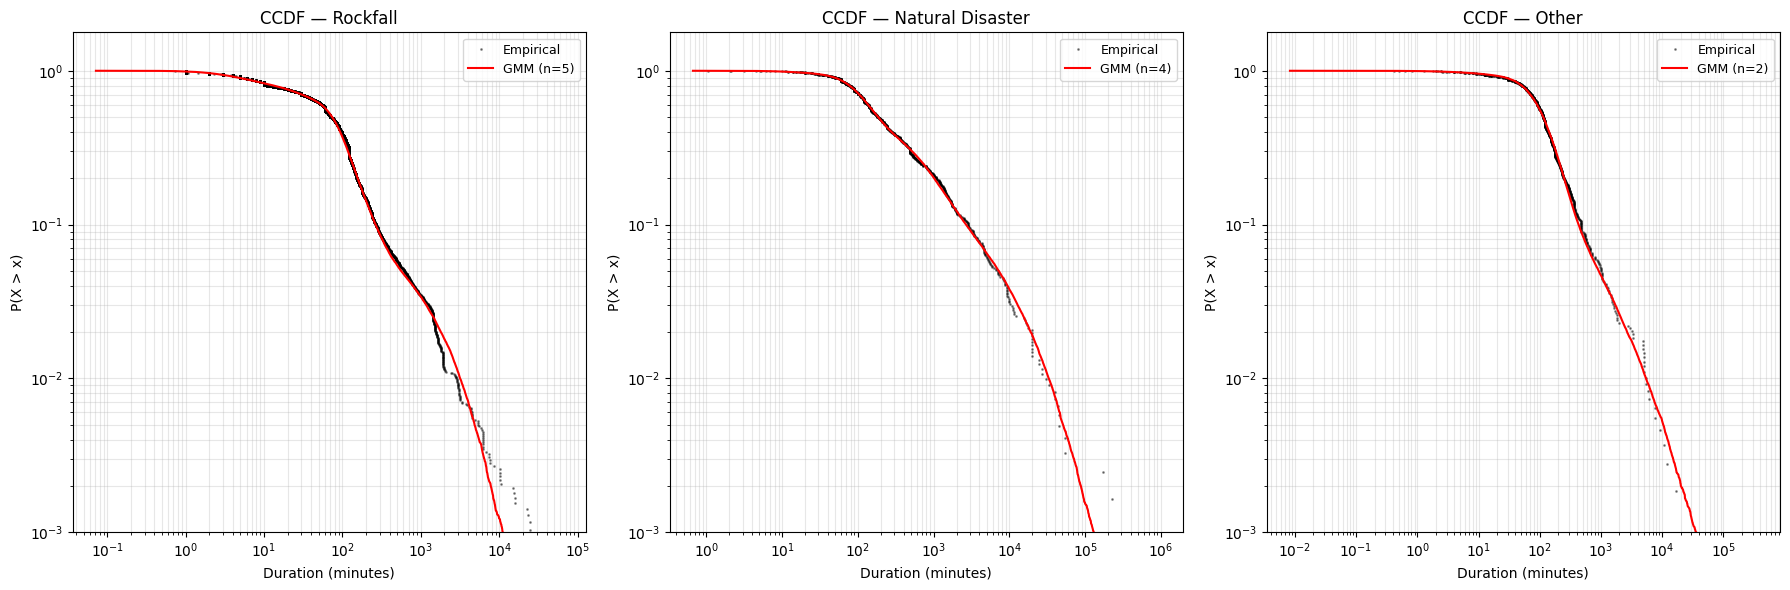

In [209]:
# 依據選定的 n_components 進行最終擬合
best_n = {
    cause: gmm_results[cause]["gmm"].n_components
    for cause in causes_fit
}

gmm_final = {}

for cause in causes_fit:
    data     = df[df["Cause"] == cause]["Duration (minutes)"].values
    log_data = np.log(data).reshape(-1, 1)

    gmm = GaussianMixture(n_components=best_n[cause], random_state=42, max_iter=500)
    gmm.fit(log_data)
    gmm_final[cause] = gmm

    print(f"=== {cause} (n={best_n[cause]}) ===")
    for k in range(best_n[cause]):
        print(f"  Component {k+1}: weight={gmm.weights_[k]:.4f}, "
              f"μ={gmm.means_[k][0]:.4f}, σ={np.sqrt(gmm.covariances_[k][0][0]):.4f}")
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cause in enumerate(causes_fit):
    data    = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    ccdf    = 1 - np.arange(1, len(data) + 1) / len(data)

    samples, _ = gmm_final[cause].sample(100_000)
    samples    = np.sort(np.exp(samples.flatten()))
    ccdf_gmm   = 1 - np.arange(1, len(samples) + 1) / len(samples)

    ax = axes[i]
    ax.loglog(data, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical")
    ax.loglog(samples, ccdf_gmm, "r-", linewidth=1.5,
              label=f"GMM (n={best_n[cause]})")
    ax.set_ylim(bottom=1e-3)
    ax.set_title(f"CCDF — {cause}")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("P(X > x)")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# 7. 相對誤差評估

本節對 GMM 擬合結果進行全面的擬合品質評估，與電網分析（03_grid_data_analysis）結構一致：

* **7.1 分位數比較**：在關鍵超越機率（P50／P25／P10／P5／P1）下，量化 GMM 估計值與實際值的誤差
* **7.2 逐點 CCDF 相對誤差**：逐點計算實際 CCDF 與 GMM 理論 CCDF 的相對誤差，得出整體擬合品質統計與離散化分布
* **7.3 保守設計驗證（ΔE[T]）**：驗證 GMM 全域擬合在整體期望值層面的偏向

> **GMM CCDF 精確計算方式**：GMM 對 log(Duration) 建模，CCDF 在原始空間為加權常態 CDF 的加總，不需 Monte Carlo 取樣即可精確求得：
>
> $$P(X > x) = 1 - \sum_{k=1}^{K} \pi_k \cdot \Phi\!\left(\frac{\ln x - \mu_k}{\sigma_k}\right)$$

## 7.1 分位數比較（Quantile Comparison）

在關鍵超越機率下，比較 GMM 估計值與實際經驗值，作為初步擬合品質確認。

In [210]:
# 分位數比較
quantiles = [0.50, 0.25, 0.10, 0.05, 0.01]
labels_q  = ["P50", "P25", "P10", "P5", "P1"]

for cause in causes_fit:
    data    = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    n       = len(data)

    # GMM Monte Carlo 取樣
    samples, _ = gmm_final[cause].sample(500_000)
    samples    = np.sort(np.exp(samples.flatten()))

    rows = []
    for q, label in zip(quantiles, labels_q):
        # 實際值：經驗 CCDF 對應的分位數
        x_empirical = np.quantile(data, 1 - q)

        # GMM 預測值
        x_gmm = np.quantile(samples, 1 - q)

        # 相對誤差
        rel_err = abs(x_gmm - x_empirical) / x_empirical * 100

        rows.append({
            "超越機率"        : label,
            "實際 Duration(分)" : round(x_empirical, 1),
            "GMM 預測（分）"   : round(x_gmm, 1),
            "誤差 (%)"        : round(rel_err, 1),
        })

    result = pd.DataFrame(rows).set_index("超越機率")
    print(f"=== {cause} ===")
    display(result)
   

=== Rockfall ===


,實際 Duration(分),GMM 預測（分）,誤差 (%)
超越機率,,,
P50,71.0,74.2,4.5
P25,131.0,134.4,2.6
P10,268.1,267.4,0.3
P5,614.0,570.6,7.1
P1,2805.1,3233.5,15.3


=== Natural Disaster ===


,實際 Duration(分),GMM 預測（分）,誤差 (%)
超越機率,,,
P50,184.5,183.7,0.4
P25,670.5,721.2,7.6
P10,2829.2,2676.0,5.4
P5,6985.5,7335.4,5.0
P1,29698.2,33458.3,12.7


=== Other ===


,實際 Duration(分),GMM 預測（分）,誤差 (%)
超越機率,,,
P50,115.0,113.8,1.0
P25,205.5,211.4,2.9
P10,480.0,433.6,9.7
P5,1020.0,908.0,11.0
P1,5464.1,5366.0,1.8


## 7.2 逐點 CCDF 相對誤差

* **原理**

  對每個資料點 $x_i$，計算實際 CCDF 與 GMM 理論 CCDF 之間的相對誤差：

  $$\text{Relative Error} = \frac{|P_{\text{empirical}}(X > x_i) - P_{\text{GMM}}(X > x_i)|}{P_{\text{empirical}}(X > x_i)}$$

* **誤差判斷標準**

  | 誤差範圍 | 評估 |
  |---------|------|
  | < 5% | 擬合非常好 |
  | 5 ~ 10% | 擬合良好，可接受 |
  | 10 ~ 20% | 擬合尚可，需注意偏離區間 |
  | > 20% | 擬合較差，分布假設可能不適用 |

In [211]:
from scipy.stats import norm as sp_norm

# ── GMM CCDF 精確計算（加權常態 CDF 加總，log 空間）────────────────────
def gmm_ccdf_at(x_vals, gmm):
    """對 log-space GMM 在 x_vals（分鐘）計算精確 CCDF = 1 - CDF"""
    log_x = np.log(np.asarray(x_vals, dtype=float))
    cdf = np.zeros(len(log_x))
    for k in range(gmm.n_components):
        mu_k    = gmm.means_[k, 0]
        sigma_k = np.sqrt(gmm.covariances_[k, 0, 0])
        cdf    += gmm.weights_[k] * sp_norm.cdf((log_x - mu_k) / sigma_k)
    return 1.0 - cdf

# ── 一般統計 ─────────────────────────────────────────────────────────────
print("── 相對誤差分布（一般統計）──")
for cause in causes_fit:
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    n    = len(data)

    ccdf_empirical = 1 - np.arange(1, n + 1) / n
    ccdf_gmm_vals  = gmm_ccdf_at(data, gmm_final[cause])

    mask       = ccdf_empirical > 0
    ccdf_emp_v = ccdf_empirical[mask]
    ccdf_gmm_v = ccdf_gmm_vals[mask]

    rel_err = np.abs(ccdf_emp_v - ccdf_gmm_v) / ccdf_emp_v

    print(f"\n=== {cause} (n={n}) ===")
    print(f"  中位數相對誤差 : {np.median(rel_err)*100:.2f}%")
    print(f"  平均相對誤差   : {np.mean(rel_err)*100:.2f}%")
    print(f"  最大相對誤差   : {rel_err.max()*100:.2f}%")

── 相對誤差分布（一般統計）──

=== Rockfall (n=7790) ===
  中位數相對誤差 : 1.56%
  平均相對誤差   : 2.77%
  最大相對誤差   : 89.28%

=== Natural Disaster (n=1219) ===
  中位數相對誤差 : 0.88%
  平均相對誤差   : 2.27%
  最大相對誤差   : 82.85%

=== Other (n=1088) ===
  中位數相對誤差 : 1.68%
  平均相對誤差   : 3.51%
  最大相對誤差   : 127.97%


In [212]:
# ── 離散化統計 ───────────────────────────────────────────────────────────
bins_err   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, np.inf)]
labels_err = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]

for cause in causes_fit:
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    n    = len(data)

    ccdf_empirical = 1 - np.arange(1, n + 1) / n
    ccdf_gmm_vals  = gmm_ccdf_at(data, gmm_final[cause])

    mask    = ccdf_empirical > 0
    rel_err = np.abs(ccdf_empirical[mask] - ccdf_gmm_vals[mask]) / ccdf_empirical[mask]

    rows       = []
    cumulative = 0.0
    for (lo, hi), label in zip(bins_err, labels_err):
        cnt  = int(((rel_err >= lo) & (rel_err < hi)).sum())
        pct  = cnt / len(rel_err) * 100
        cumulative += pct
        rows.append({"誤差區間": label, "點數": cnt,
                     "比例 (%)": round(pct, 1), "累積比例 (%)": round(cumulative, 1)})

    err_table = pd.DataFrame(rows).set_index("誤差區間")
    pct_10 = (rel_err < 0.10).mean() * 100
    pct_20 = (rel_err < 0.20).mean() * 100

    print(f"\n=== {cause} (< 10%: {pct_10:.1f}%，< 20%: {pct_20:.1f}%) ===")
    display(err_table)


=== Rockfall (< 10%: 97.8%，< 20%: 98.3%) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,7010,90.0,90.0
5 ~ 10%（良好）,611,7.8,97.8
10 ~ 20%（尚可）,39,0.5,98.3
> 20%（偏差）,129,1.7,100.0



=== Natural Disaster (< 10%: 97.0%，< 20%: 98.4%) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,1093,89.7,89.7
5 ~ 10%（良好）,89,7.3,97.0
10 ~ 20%（尚可）,16,1.3,98.4
> 20%（偏差）,20,1.6,100.0



=== Other (< 10%: 95.1%，< 20%: 99.0%) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,799,73.5,73.5
5 ~ 10%（良好）,235,21.6,95.1
10 ~ 20%（尚可）,42,3.9,99.0
> 20%（偏差）,11,1.0,100.0


## 7.3 保守設計驗證（ΔE[T]）

可靠度評估真正關心的是**長期多次事件下的期望修復時間**，因此以下結果成立即代表 GMM 估計偏保守側：

> 若 $\Delta E[T] > 0$，代表模型在各超越機率點的修復時間估計期望值偏向高估，模擬結果具保守性。

| 指標 | 計算方式 | 說明 |
|------|----------|------|
| 逐點誤差 $\Delta T_i$ | $x_{\text{GMM}}(p_i) - x_{\text{empirical}}(p_i)$ | 正值代表高估，負值代表低估 |
| 誤差期望值 $\Delta E[T]$ | $\frac{1}{n}\sum_{i=1}^{n} \Delta T_i$ | 各事件誤差的算術平均，反映模擬的整體偏向 |
| 相對高估比例 | $\frac{\Delta E[T]}{\bar{x}} \times 100\%$ | 相對於歷史平均修復時間的高估幅度 |

In [213]:
# ── 7.3 保守設計驗證（ΔE[T]）────────────────────────────────────────────
# GMM 逆函數以數值插值近似（取代 Monte Carlo 取樣）：
#   1. 在 log-space 建細密格點，用 gmm_ccdf_at() 精確算 CCDF
#   2. CCDF 單調遞減 → 反轉後以 np.interp 反查每個 p_i 對應的 x

print("── 保守設計驗證 ──")
for cause in causes_fit:
    data = np.sort(df[df["Cause"] == cause]["Duration (minutes)"].values)
    n    = len(data)

    ccdf_empirical = 1 - np.arange(1, n + 1) / n
    mask           = ccdf_empirical > 0
    p_i            = ccdf_empirical[mask]
    x_empirical    = data[mask]
    actual_mean    = data.mean()

    # GMM 逆函數：數值插值（確定性，無隨機誤差）
    x_grid      = np.logspace(np.log10(data.min() * 0.5),
                              np.log10(data.max() * 10), 10_000)
    ccdf_grid   = gmm_ccdf_at(x_grid, gmm_final[cause])   # 精確 CCDF，單調遞減
    x_estimated = np.interp(p_i, ccdf_grid[::-1], x_grid[::-1])  # 反轉使 xp 嚴格遞增

    delta_T   = x_estimated - x_empirical
    delta_E_T = delta_T.mean()
    pct_delta = delta_E_T / actual_mean * 100

    print(f"\n=== {cause} ===")
    print(f"  誤差期望值 ΔE[T] : {delta_E_T:+.2f} min  ({delta_E_T/60:+.4f} hr)")
    print(f"  相對高估比例     : {pct_delta:+.2f}%")
    print(f"  方向             : {'高估（保守）' if delta_E_T > 0 else '低估（非保守）'}")

── 保守設計驗證 ──

=== Rockfall ===
  誤差期望值 ΔE[T] : -19.78 min  (-0.3297 hr)
  相對高估比例     : -8.59%
  方向             : 低估（非保守）

=== Natural Disaster ===
  誤差期望值 ΔE[T] : -173.29 min  (-2.8881 hr)
  相對高估比例     : -7.52%
  方向             : 低估（非保守）

=== Other ===
  誤差期望值 ΔE[T] : +19.41 min  (+0.3235 hr)
  相對高估比例     : +5.53%
  方向             : 高估（保守）


# 8. 存檔

In [214]:
import json
import os

params_path = os.path.join(DATA_DIR, "road_repair_params.json")

road_params = {}

# 高雄市 Cause 發生比例
road_params["kaohsiung_cause_ratio"] = {
    row["Cause"]: row["Ratio"]
    for _, row in kaohsiung_ratio.iterrows()
}

# 各 Cause GMM 參數
road_params["gmm"] = {}
for cause in causes_fit:
    gmm = gmm_final[cause]
    road_params["gmm"][cause] = {
        "n_components" : int(gmm.n_components),
        "weights"      : gmm.weights_.tolist(),
        "means"        : gmm.means_.flatten().tolist(),
        "stds"         : np.sqrt(gmm.covariances_.flatten()).tolist(),
    }

with open(params_path, "w") as f:
    json.dump(road_params, f, indent=2, ensure_ascii=False)

print(json.dumps(road_params, indent=2, ensure_ascii=False))

{
  "kaohsiung_cause_ratio": {
    "Other": 0.5722,
    "Natural Disaster": 0.2406,
    "Rockfall": 0.1818,
    "Traffic Accident": 0.0053
  },
  "gmm": {
    "Rockfall": {
      "n_components": 5,
      "weights": [
        0.4033584694292433,
        0.24761988931358772,
        0.13007929966472997,
        0.1483772296474493,
        0.07056511194498971
      ],
      "means": [
        4.543309543992644,
        1.8203124009258775,
        5.306787120660873,
        3.502105743183755,
        6.897812948497893
      ],
      "stds": [
        0.407351437742876,
        1.0363891346455736,
        0.47638440960963724,
        0.565895280418118,
        1.107514205622385
      ]
    },
    "Natural Disaster": {
      "n_components": 4,
      "weights": [
        0.12787626080547093,
        0.5004995432189411,
        0.2728715325116117,
        0.09875266346397621
      ],
      "means": [
        8.517434934081297,
        4.755374328716306,
        6.5410113529253096,
        3.57